Stage 2a — Feature construction

Builds the model frame and writes it to `datasets/processed/model_frame.csv`
alongside a feature dictionary, so the forecasting notebook loads one artefact
rather than rebuilding features it cannot see.

Every transform is trailing-only. There is no centred window and no negative
shift in this file.

In [2]:
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 140)

REPORTS = "results/reports"
PROCESSED = "datasets/processed"
os.makedirs(REPORTS, exist_ok=True)

from src.data.loaders import attach_weekly
from src.features.build import build_feature_frame

daily = pd.read_csv(f"{PROCESSED}/master_daily.csv", parse_dates=["date"]).set_index("date").sort_index()
weekly = pd.read_csv(f"{PROCESSED}/master_weekly.csv", parse_dates=["week_start"]).set_index("week_start").sort_index()

merged = attach_weekly(daily, weekly).drop(columns=["published_on"], errors="ignore")
merged = merged.select_dtypes("number").ffill().dropna()
print("merged frame:", merged.shape)
print(merged.columns.tolist())

merged frame: (376, 7)
['brent_close', 'rhetoric_index', 'tanker_rate_usd', 'acled_events', 'acled_fatalities', 'acled_fatalities_revised', 'hormuz_severity']


Lags

Positive lags only. A negative lag would pull future values backwards, which is
leakage no train/test split can catch.

In [4]:
LAGS = [1, 2, 3, 5, 10]
HORIZONS = (1, 5)
print("lags:", LAGS)
print("horizons:", HORIZONS)

X, y = build_feature_frame(merged, price_col="brent_close", lags=LAGS, horizons=HORIZONS)
print()
print("X", X.shape, " y", list(y.columns))
print("first feature columns:", X.columns[:6].tolist())

lags: [1, 2, 3, 5, 10]
horizons: (1, 5)

X (264, 70)  y ['h1', 'h5']
first feature columns: ['realised_return_lag1', 'realised_return_lag2', 'realised_return_lag3', 'realised_return_lag5', 'realised_return_lag10', 'rv21_lag1']


Feature dictionary

In [6]:
rows = []
for col in X.columns:
    base = col.split("_lag")[0]
    lag = int(col.split("_lag")[-1]) if "_lag" in col else 0
    rows.append({"feature": col, "base": base, "lag": lag,
                  "mean": round(float(X[col].mean()), 6),
                  "std": round(float(X[col].std()), 6),
                  "nulls": int(X[col].isna().sum())})
fdict = pd.DataFrame(rows)
print(fdict.head(15).to_string(index=False))
print()
print("features by base variable:")
print(fdict.groupby("base").size().to_string())
fdict.to_csv(f"{REPORTS}/feature_dictionary.csv", index=False)

              feature            base  lag      mean      std  nulls
 realised_return_lag1 realised_return    1 -0.000032 0.015377      0
 realised_return_lag2 realised_return    2 -0.000114 0.015172      0
 realised_return_lag3 realised_return    3  0.000107 0.015312      0
 realised_return_lag5 realised_return    5  0.000130 0.015011      0
realised_return_lag10 realised_return   10  0.000603 0.015161      0
            rv21_lag1            rv21    1  0.014017 0.005359      0
            rv21_lag2            rv21    2  0.013983 0.005342      0
            rv21_lag3            rv21    3  0.013954 0.005326      0
            rv21_lag5            rv21    5  0.013918 0.005275      0
           rv21_lag10            rv21   10  0.013875 0.005113      0
  rhetoric_index_lag1  rhetoric_index    1  0.182720 0.225152      0
  rhetoric_index_lag2  rhetoric_index    2  0.181980 0.222274      0
  rhetoric_index_lag3  rhetoric_index    3  0.185408 0.217594      0
  rhetoric_index_lag5  rhetoric_in

Target checks

In [8]:
for h in HORIZONS:
    col = f"h{h}"
    print(f"{col}  n={len(y[col])}  mean={y[col].mean():.6f}  std={y[col].std():.6f}")

price = merged["brent_close"].reindex(X.index)
worst = X.corrwith(y[f"h{HORIZONS[0]}"]).abs().sort_values(ascending=False)
print()
print("highest absolute correlation between any feature and the target:")
print(worst.head(5).round(4).to_string())
print()
if float(worst.iloc[0]) > 0.95:
    print("WARNING: a feature is near-perfectly correlated with the target, which")
    print("is what a leaked target looks like.")
else:
    print("No feature exceeds 0.95 against the target, so no obvious target leak.")

h1  n=264  mean=0.000061  std=0.015476
h5  n=264  mean=0.000906  std=0.035987

highest absolute correlation between any feature and the target:
rhetoric_index_lag10             0.1803
hormuz_severity_lag3             0.1534
hormuz_severity_lag5             0.1471
acled_fatalities_revised_lag1    0.1458
acled_fatalities_lag1            0.1401

No feature exceeds 0.95 against the target, so no obvious target leak.


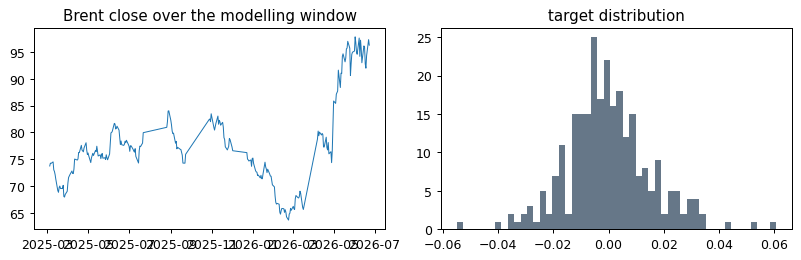

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(price.index, price, lw=.8)
axes[0].set_title("Brent close over the modelling window")
axes[1].hist(y[f"h{HORIZONS[0]}"].dropna(), bins=50, color="#678")
axes[1].set_title("target distribution")
plt.tight_layout()

In [10]:
frame = X.join(y)
frame.to_csv(f"{PROCESSED}/model_frame.csv")
print("wrote", f"{PROCESSED}/model_frame.csv", frame.shape)

wrote datasets/processed/model_frame.csv (264, 72)
